Explained variance ratio: [0.44272026 0.18971182]
Total variance explained by the first two components: 0.63


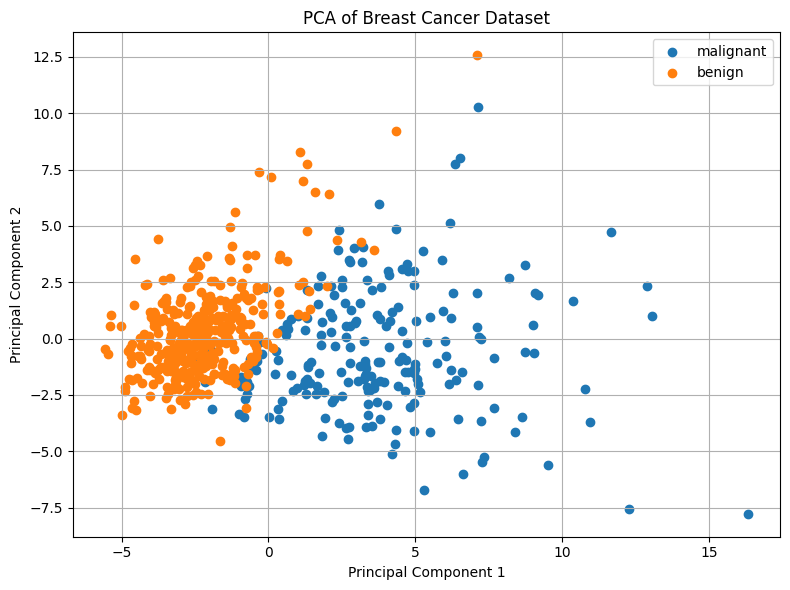

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Load the dataset
cancer = load_breast_cancer()
x = cancer.data              
y = cancer.target           
feature_names = cancer.feature_names
target_names = cancer.target_names

#Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

#Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

#Explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained_variance}")
print(f"Total variance explained by the first two components: {np.sum(explained_variance):.2f}")

#Create DataFrame for plotting
df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

#Plot PCA results
plt.figure(figsize=(8, 6))
for target, label in enumerate(target_names):
    subset = df_pca[df_pca['target'] == target]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Breast Cancer Dataset')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
